# Model Comparison with Nested Slice Sampling

tengri's other inference methods (geoVI, Ray Tracing, NUTS) target the
**posterior** — they tell you *what* the parameters are given a model. But
they cannot tell you *which model is better*. For that you need the
**Bayesian evidence** (marginal likelihood):

$$\mathcal{Z} = \int \mathcal{L}(\boldsymbol{\theta})\,\pi(\boldsymbol{\theta})\,d\boldsymbol{\theta}$$

This notebook introduces **Nested Slice Sampling** (NSS; Yallup, Kroupa &
Handley 2026), tengri's evidence computation method. It uses Hit-and-Run
Slice Sampling (HRSS) as the inner kernel to explore the constrained prior,
accumulating the evidence integral as it compresses the prior volume.

**Scope:** NSS is restricted to smooth (non-stochastic) parametric models
where D ≲ 30. For the high-dimensional stochastic GP model (D ~ 137),
use geoVI or Ray Tracing.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    ParamSpec,
    Photometry,
    Uniform,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
)

## Two Competing Models

We set up two parametric SFH models with different complexity:

| Model | SFH type | Free params | Physical motivation |
|-------|----------|-------------|-------------------|
| **A** (simple) | Double power law | 5 | Smooth rise-and-fall SFH |
| **B** (complex) | Truncated skew-normal | 7 | Asymmetric SFH with truncation |

We generate mock data from Model A, then ask: **does the extra complexity
of Model B help, or does the simpler model suffice?** The Bayes factor
answers this question.

In [3]:
# --- Model A: Double power law (simple, 5 free params) ---
spec_A = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Fixed(0.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=False,
)
model_A = Model(spec_A, ssp_data, observation=obs)

# --- Model B: Truncated skew-normal (complex, 7 free params) ---
spec_B = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Fixed(0.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
    stochastic=False,
)
model_B = Model(spec_B, ssp_data, observation=obs)

print(f"Model A (double power law):      D = {spec_A.n_free}")
print(f"Model B (truncated skew-normal): D = {spec_B.n_free}")

W0325 12:08:09.684055 20197623 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Model A (double power law):      D = 6
Model B (truncated skew-normal): D = 7


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_29695/238069258.py:13: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_A = Model(spec_A, ssp_data, observation=obs)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_29695/238069258.py:30: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_B = Model(spec_B, ssp_data, observation=obs)


In [4]:
# Generate mock data from Model A (the truth)
key = jax.random.PRNGKey(42)
true_params_A = spec_A.sample(key)

# Override to a typical star-forming galaxy
true_params_A = {**true_params_A}
true_params_A["sfh_dpl_alpha"] = jnp.array(1.5)
true_params_A["sfh_dpl_beta"] = jnp.array(1.0)
true_params_A["sfh_dpl_tau_gyr"] = jnp.array(5.0)
true_params_A["met_logzsol"] = jnp.array(-0.5)
true_params_A["dust_tau_bc"] = jnp.array(0.3)

mock = model_A.mock(true_params_A, snr=20.0, key=jax.random.PRNGKey(1))
print(f"Mock photometry: {len(mock.flux_obs)} bands, SNR ≈ 20")

Mock photometry: 5 bands, SNR ≈ 20


## Running NSS

NSS is invoked via `fitter.run("nss")`. Key parameters:

| Parameter | Default | Description |
|-----------|---------|-------------|
| `n_live` | 500 | Number of live points — more = more precise evidence |
| `num_delete` | 50 | Points replaced per iteration — controls speed vs accuracy |
| `num_inner_steps` | D | HRSS walk length — longer = less correlated samples |
| `log_evidence_tol` | -3.0 | Stop when remaining evidence < e⁻³ of total |

The first call includes JIT compilation overhead (~10–30s). Subsequent
calls with the same model structure are much faster.

In [5]:
# Fit both models to the same data
fitter_A = Fitter(model_A, mock.flux_obs, mock.noise)
fitter_B = Fitter(model_B, mock.flux_obs, mock.noise)

print("Running NSS on Model A (double power law)...")
result_A = fitter_A.run(
    "nss",
    n_live=500,
    num_delete=50,
    key=jax.random.PRNGKey(0),
)

Running NSS on Model A (double power law)...
NSS: 6 parameters, 500 live points, 50 deletions/iter, 6 HRSS steps


  NSS iter 10: log Z ≈ -7.14, n_dead=500, elapsed=1.0s
  NSS iter 20: log Z ≈ -7.99, n_dead=1000, elapsed=1.2s


  NSS iter 30: log Z ≈ -8.01, n_dead=1500, elapsed=1.3s
  NSS iter 40: log Z ≈ -7.88, n_dead=2000, elapsed=1.4s


  NSS iter 50: log Z ≈ -7.98, n_dead=2500, elapsed=1.6s
  NSS iter 60: log Z ≈ -7.96, n_dead=3000, elapsed=1.7s


  NSS iter 70: log Z ≈ -7.97, n_dead=3500, elapsed=1.9s
  NSS iter 80: log Z ≈ -7.96, n_dead=4000, elapsed=2.0s


  NSS iter 90: log Z ≈ -7.96, n_dead=4500, elapsed=2.2s
  NSS iter 100: log Z ≈ -7.96, n_dead=5000, elapsed=2.4s


  NSS complete in 2.4s. log Z = -7.96, ESS = 2073


In [6]:
print("\nRunning NSS on Model B (truncated skew-normal)...")
result_B = fitter_B.run(
    "nss",
    n_live=500,
    num_delete=50,
    key=jax.random.PRNGKey(0),
)


Running NSS on Model B (truncated skew-normal)...
NSS: 7 parameters, 500 live points, 50 deletions/iter, 7 HRSS steps


  NSS iter 10: log Z ≈ -7.66, n_dead=500, elapsed=1.0s
  NSS iter 20: log Z ≈ -7.46, n_dead=1000, elapsed=1.2s


  NSS iter 30: log Z ≈ -7.47, n_dead=1500, elapsed=1.4s


  NSS iter 40: log Z ≈ -7.76, n_dead=2000, elapsed=1.6s


  NSS iter 50: log Z ≈ -7.68, n_dead=2500, elapsed=1.8s


...

  NSS iter 70: log Z ≈ -7.62, n_dead=3500, elapsed=2.3s


  NSS iter 80: log Z ≈ -7.62, n_dead=4000, elapsed=2.6s


  NSS iter 90: log Z ≈ -7.62, n_dead=4500, elapsed=2.9s


  NSS iter 100: log Z ≈ -7.62, n_dead=5000, elapsed=3.2s


  NSS complete in 3.2s. log Z = -7.62, ESS = 1898


## The Bayes Factor

The Bayes factor compares two models:

$$K = \frac{\mathcal{Z}_A}{\mathcal{Z}_B} = \exp(\log\mathcal{Z}_A - \log\mathcal{Z}_B)$$

On the Jeffreys scale:

| $|\ln K|$ | Evidence |
|-----------|----------|
| < 1 | Inconclusive |
| 1–2.5 | Moderate |
| 2.5–5 | Strong |
| > 5 | Decisive |

In [7]:
logZ_A = result_A.log_evidence
logZ_B = result_B.log_evidence
ln_K = logZ_A - logZ_B

print(f"  Model A (DPL, D={spec_A.n_free}):    log Z = {logZ_A:.2f}")
print(f"  Model B (tsnorm, D={spec_B.n_free}):  log Z = {logZ_B:.2f}")
print(f"  ln K (A vs B) = {ln_K:.2f}")
print()

if abs(ln_K) < 1:
    verdict = "Inconclusive — cannot distinguish"
elif abs(ln_K) < 2.5:
    preferred = "A" if ln_K > 0 else "B"
    verdict = f"Moderate preference for Model {preferred}"
elif abs(ln_K) < 5:
    preferred = "A" if ln_K > 0 else "B"
    verdict = f"Strong preference for Model {preferred}"
else:
    preferred = "A" if ln_K > 0 else "B"
    verdict = f"Decisive preference for Model {preferred}"

print(f"  Verdict: {verdict}")
print()
print("  (Data was generated from Model A — the Bayes factor should")
print("   prefer A, penalizing B's extra parameters via Occam's razor.)")

  Model A (DPL, D=6):    log Z = -7.96
  Model B (tsnorm, D=7):  log Z = -7.62
  ln K (A vs B) = -0.34

  Verdict: Inconclusive — cannot distinguish

  (Data was generated from Model A — the Bayes factor should
   prefer A, penalizing B's extra parameters via Occam's razor.)


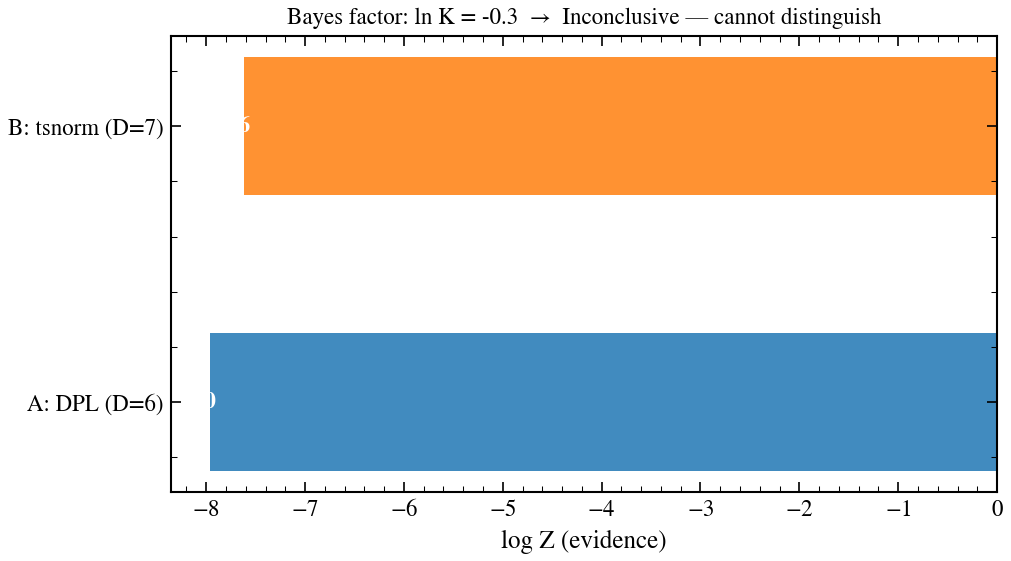

In [8]:
# --- FIGURE 1: Evidence comparison ---
fig, ax = plt.subplots(figsize=(7, 4))

bar_colors = [COLORS["rt"], COLORS["geovi"]]
labels = [f"A: DPL (D={spec_A.n_free})", f"B: tsnorm (D={spec_B.n_free})"]
logZs = [logZ_A, logZ_B]
bars = ax.barh([0, 1], logZs, color=bar_colors, alpha=0.85, height=0.5)

for bar, lz in zip(bars, logZs):
    x_pos = lz - 0.3 if lz < 0 else lz + 0.1
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"{lz:.1f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white" if lz < 0 else "k",
    )

ax.set_yticks([0, 1])
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("log Z (evidence)", fontsize=12)
ax.set_title(f"Bayes factor: ln K = {ln_K:.1f}  →  {verdict}", fontsize=11)
ax.axvline(0, color="k", lw=0.5, ls=":")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_evidence_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## Posterior Samples from NSS

NSS produces posterior samples as a byproduct — they come from importance
resampling of the dead and live points weighted by prior volume.

In [9]:
print("Model A posterior:")
print(result_A.summary_table())
print()
print("Model B posterior:")
print(result_B.summary_table())

Model A posterior:
Posterior  method: NSS (Yallup+2026)  samples: 1000  wall_time: 2.4s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_bump_strength              0.0000    0.0000    0.0000       —
  dust_delta                      0.0000    0.0000    0.0000       —
  dust_f_obscuration              0.0000    0.0000    0.0000       —
  dust_slope                     -0.7000   -0.7000   -0.7000       —
  dust_tau_bc                     0.8943    0.2899    1.6308       —
  dust_tau_diff                   0.5000    0.5000    0.5000       —
  met_alpha_fe                    0.0000    0.0000    0.0000       —
  met_logzsol                    -0.8480   -1.1020   -0.5291       —
  noise_dof                       0.0000    0.0000    0.0000       —
  noise_frac_cal   

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

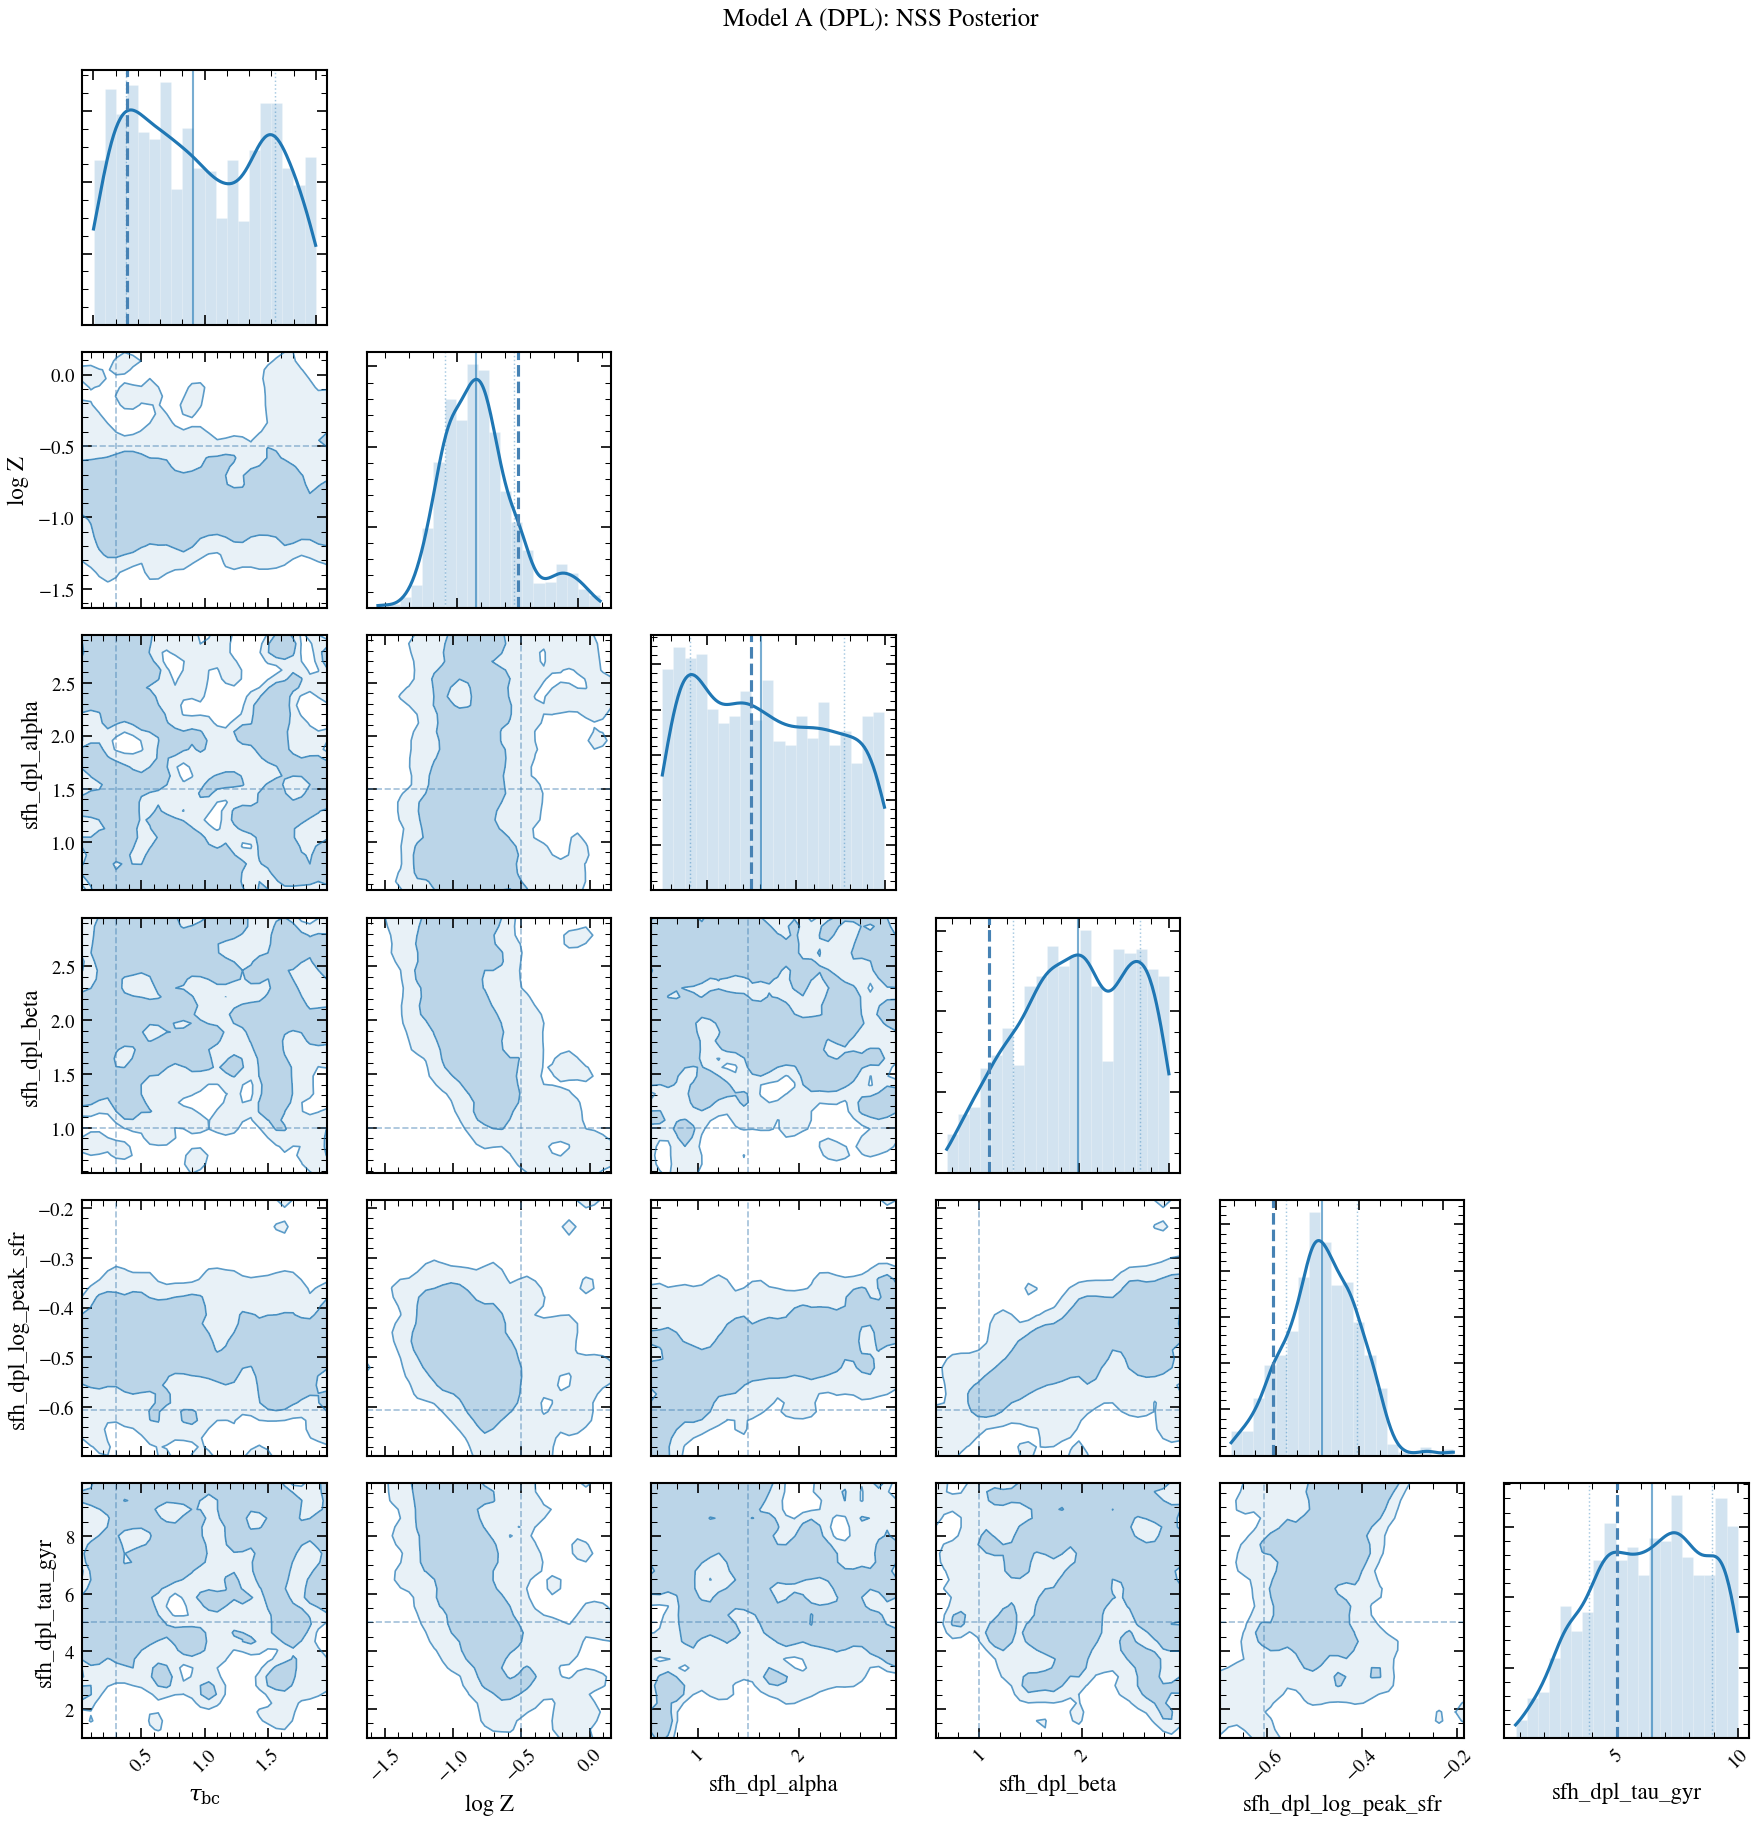

In [10]:
# --- FIGURE 2: Corner plot for Model A ---
fig_corner = result_A.plot_corner(truths=true_params_A, color=COLORS["rt"])
if fig_corner is not None:
    fig_corner.suptitle("Model A (DPL): NSS Posterior", y=1.02, fontsize=12)
    plt.savefig(os.path.join(FIGDIR, "fig02_corner_model_A.png"), dpi=150, bbox_inches="tight")
plt.show()

## NSS vs geoVI: Same Posteriors, Only NSS Gives Evidence

For the same model, NSS and geoVI should recover similar posteriors. The
key difference: NSS also computes log Z, enabling model comparison.

In [11]:
# Run geoVI on Model A for comparison
print("Running geoVI on Model A for posterior comparison...")
result_map_A = fitter_A.run(
    "map",
    n_steps=500,
    verbose=False,
)

t0_compile_geovi = time.perf_counter()
fitter_A.compile(verbose=False)
t_compile_geovi = time.perf_counter() - t0_compile_geovi

t0_run_geovi = time.perf_counter()
result_geovi_A = fitter_A.run(
    "native_geovi",
    n_iterations=15,
    n_samples=6,
    n_seeds=3,
    n_posterior_samples=2000,
    init_from=result_map_A,
    verbose=False,
)
t_run_geovi = time.perf_counter() - t0_run_geovi

print(f"  geoVI compile: {t_compile_geovi:.1f}s | runtime: {t_run_geovi:.1f}s")
print(f"  NSS wall time: {result_A.wall_time_s:.1f}s")

Running geoVI on Model A for posterior comparison...


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0325 12:08:28.341442 20197496 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 12:09:13.392730 20197496 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 12:09:18.147413 20197496 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  geoVI compile: 39.4s | runtime: 17.4s
  NSS wall time: 2.4s


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

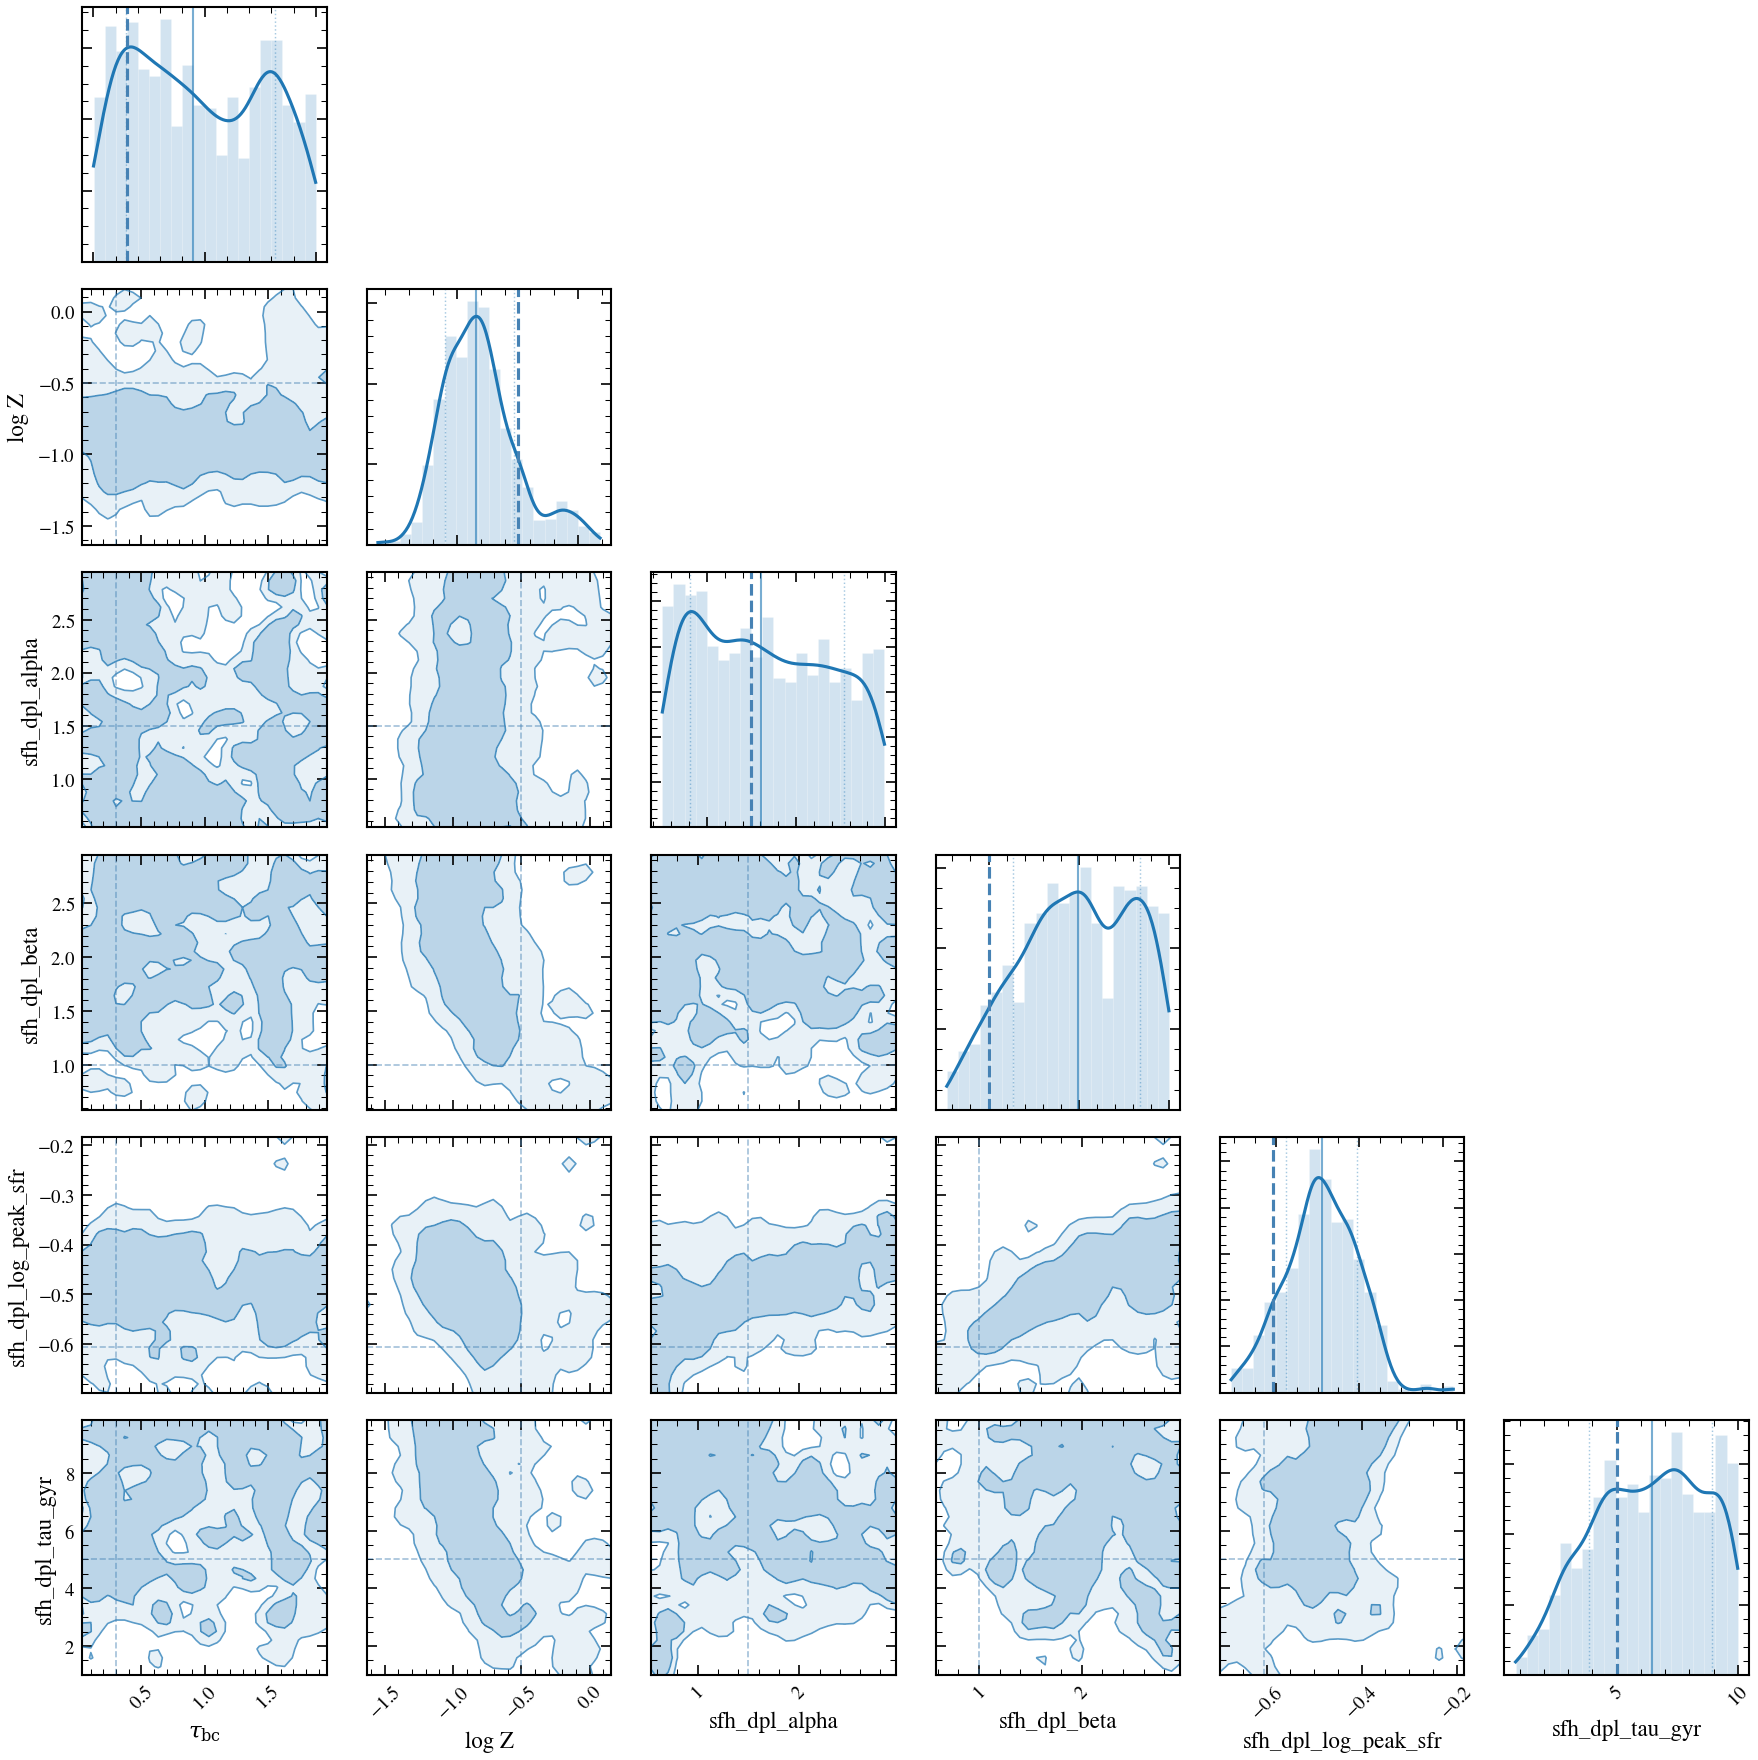

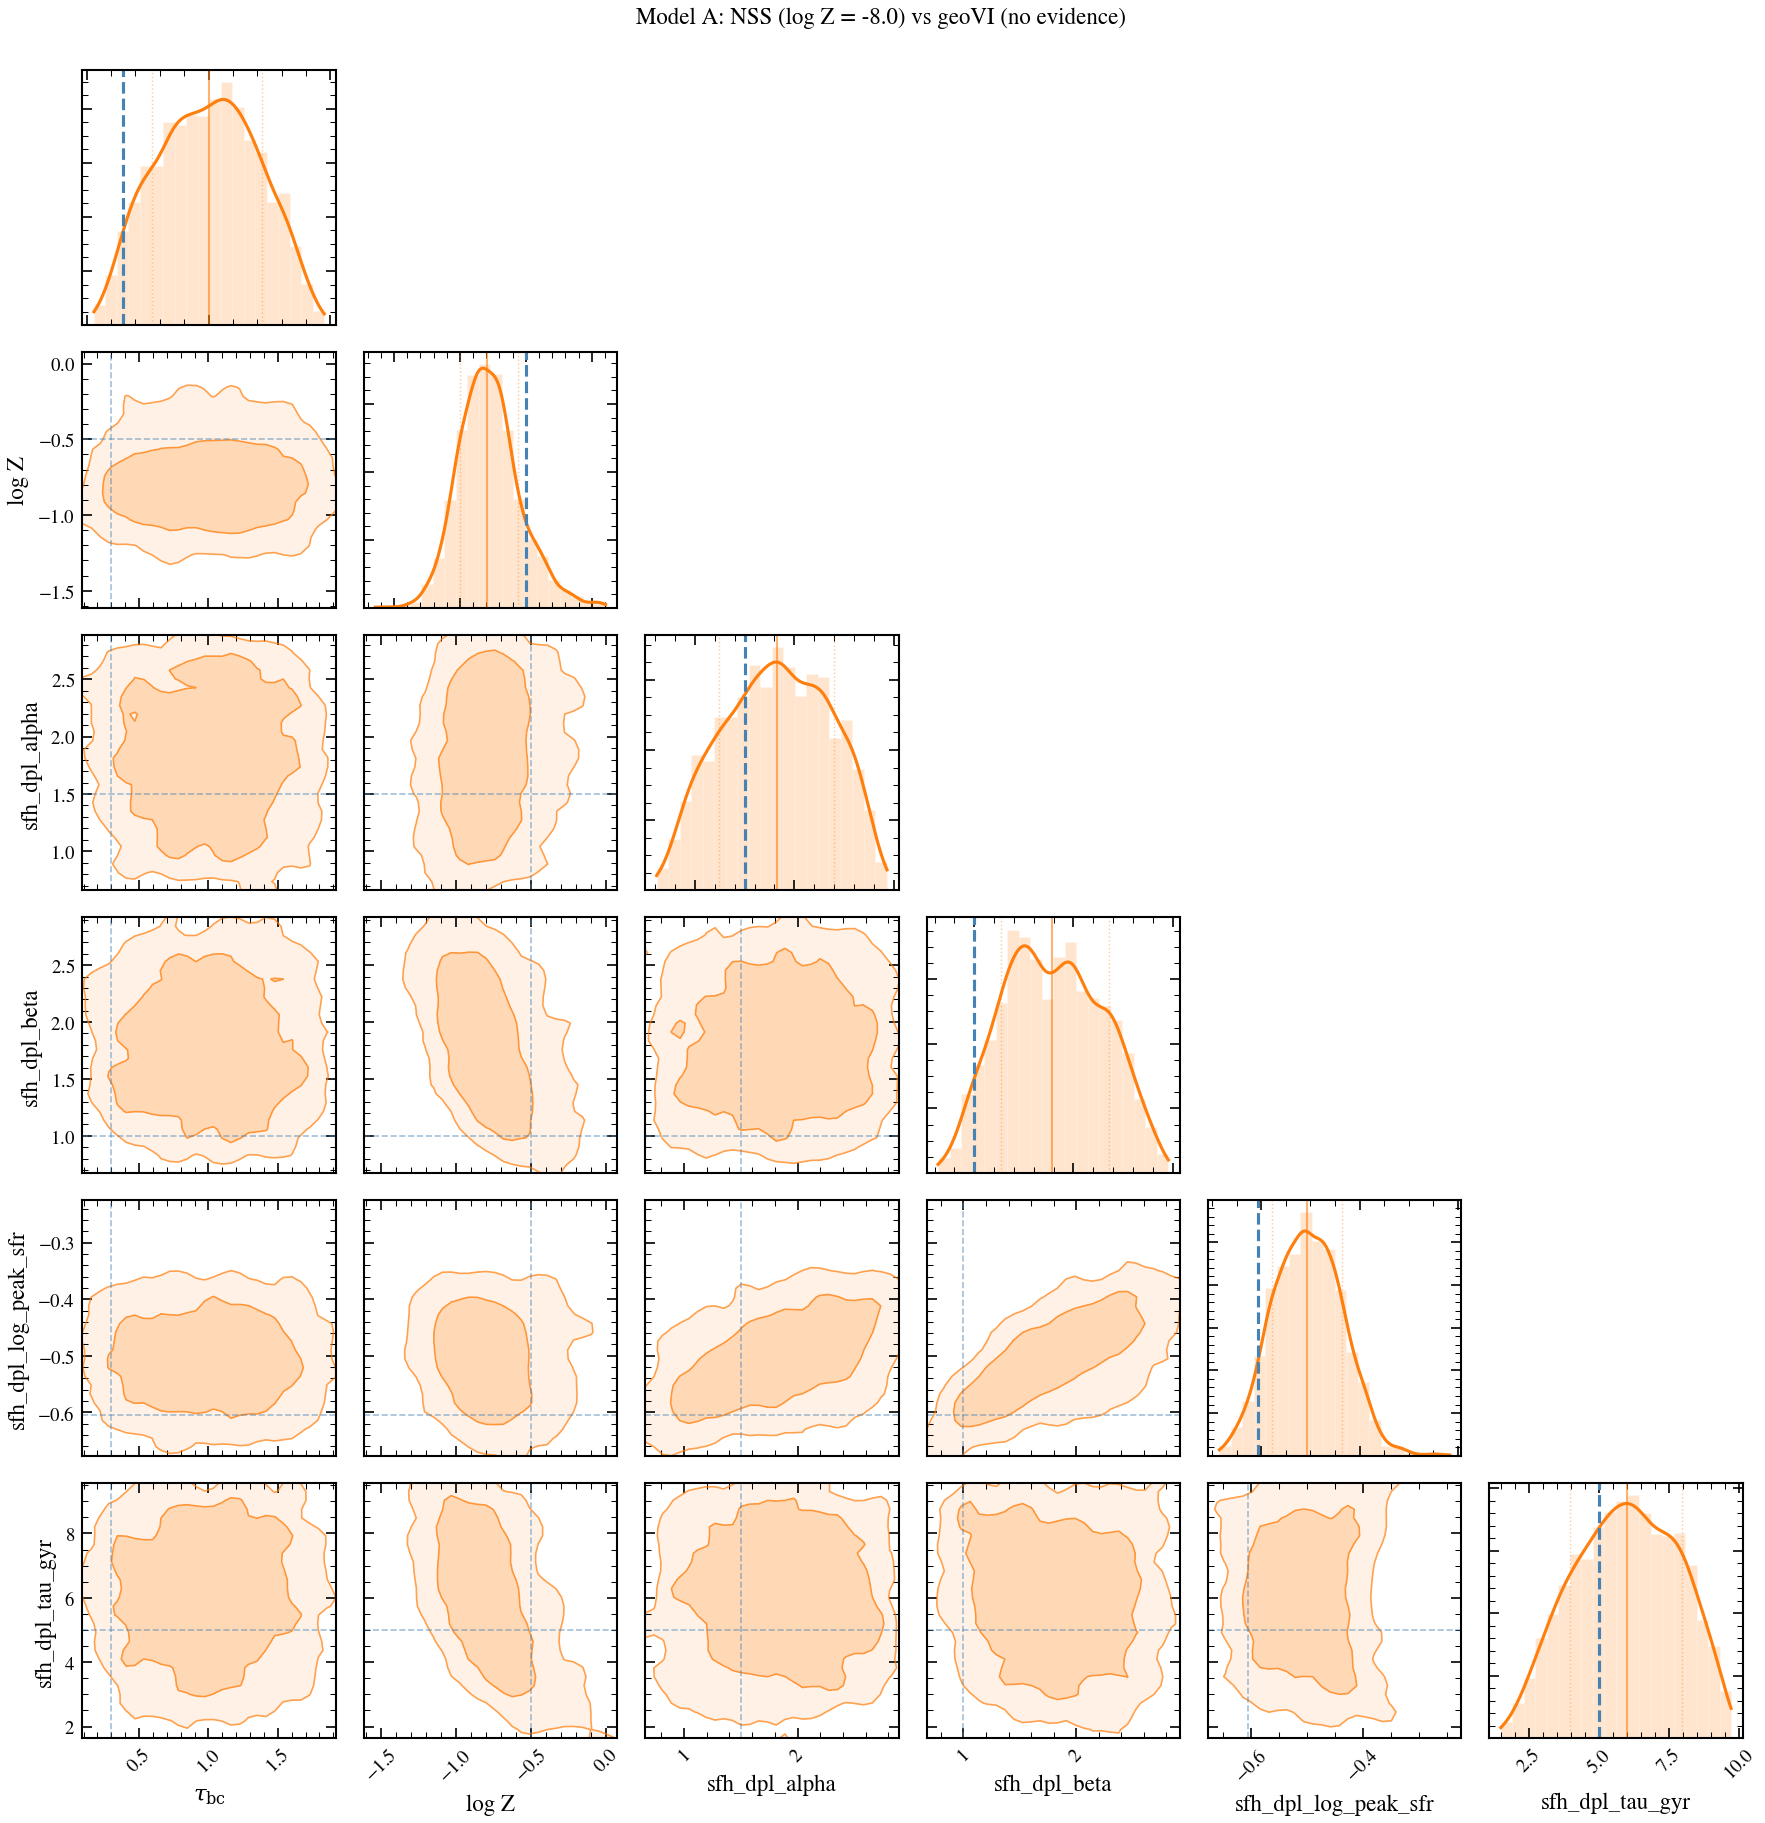

In [12]:
# --- FIGURE 3: NSS vs geoVI corner comparison ---
fig = plot_corner_comparison(
    [result_A, result_geovi_A],
    labels=["NSS", "native_geovi"],
    colors=[COLORS["rt"], COLORS["geovi"]],
    truths=true_params_A,
)
if fig is not None:
    fig.suptitle(
        f"Model A: NSS (log Z = {logZ_A:.1f}) vs geoVI (no evidence)",
        y=1.02,
        fontsize=11,
    )
    plt.savefig(os.path.join(FIGDIR, "fig03_nss_vs_geovi.png"), dpi=150, bbox_inches="tight")
plt.show()

## Diagnostics

NSS provides several diagnostics:

- **ESS** (effective sample size): how many independent posterior samples
- **n_iterations**: number of NS contraction steps
- **n_dead**: total dead points (evidence integral resolution)

In [13]:
for name, result in [("Model A", result_A), ("Model B", result_B)]:
    d = result.diagnostics
    print(f"  {name}:")
    print(f"    log Z       = {d['log_evidence']:.2f}")
    print(f"    ESS         = {d['ess']:.0f}")
    print(f"    iterations  = {d['n_iterations']}")
    print(f"    dead points = {d['n_dead']}")
    print(f"    wall time   = {result.wall_time_s:.1f}s")
    print()

  Model A:
    log Z       = -7.96
    ESS         = 2073
    iterations  = 102
    dead points = 5100
    wall time   = 2.4s

  Model B:
    log Z       = -7.62
    ESS         = 1898
    iterations  = 100
    dead points = 5000
    wall time   = 3.2s



## Model A: Posterior Validation

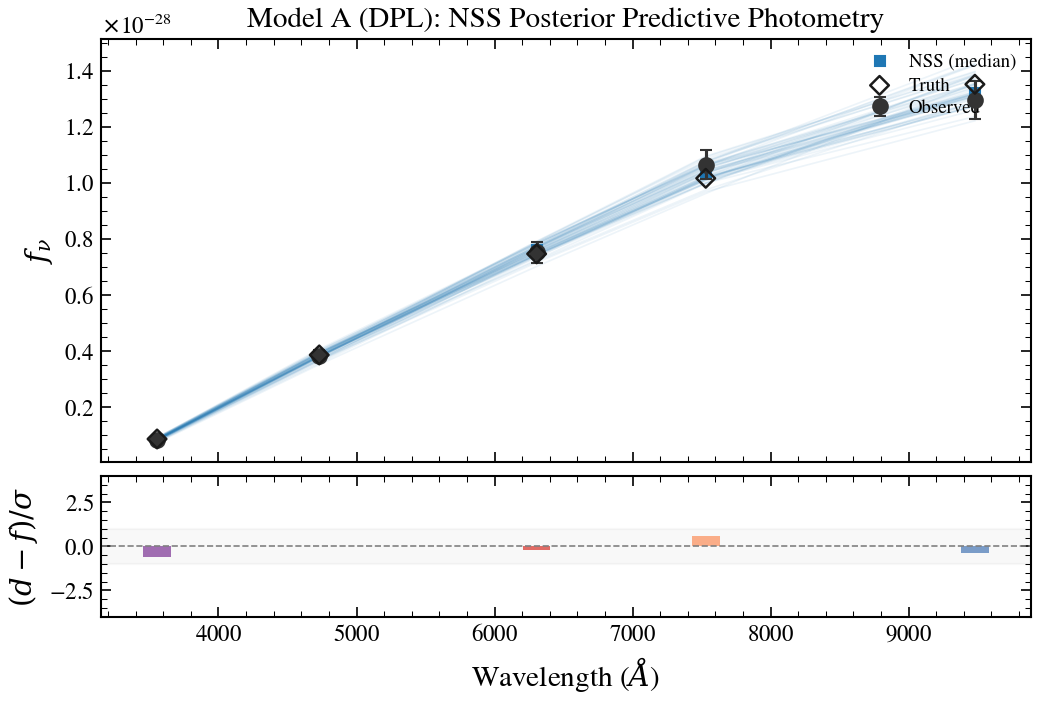

In [14]:
# --- FIGURE 4: Posterior predictive photometry for Model A ---
phot_config = obs.photometry
wave_eff = np.array([float(jnp.mean(fc.wave)) for fc in phot_config.filters])

n_draws = 50
posterior_phot_A = []
for i in range(n_draws):
    idx = i % len(next(iter(result_A.samples.values())))
    s_i = {k: v[idx] for k, v in result_A.samples.items()}
    posterior_phot_A.append(np.array(model_A.predict_photometry(s_i)))
posterior_phot_A = np.array(posterior_phot_A)

phot_true_A = np.array(model_A.predict_photometry(true_params_A))

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(8, 5),
    height_ratios=[3, 1],
    sharex=True,
)
fig.subplots_adjust(hspace=0.05)

for draw in posterior_phot_A:
    ax_top.plot(wave_eff, draw, "-", color=COLORS["rt"], alpha=0.08, lw=0.8)
median_pred_A = np.median(posterior_phot_A, axis=0)
ax_top.plot(wave_eff, median_pred_A, "s", ms=5, color=COLORS["rt"], zorder=4, label="NSS (median)")
ax_top.errorbar(
    wave_eff,
    np.array(mock.flux_obs),
    yerr=np.array(mock.noise),
    fmt="o",
    ms=7,
    color=COLORS["data"],
    capsize=3,
    zorder=5,
    label="Observed",
)
ax_top.scatter(
    wave_eff,
    phot_true_A,
    marker="D",
    s=40,
    facecolors="none",
    edgecolors=COLORS["truth"],
    linewidths=1.2,
    zorder=6,
    label="Truth",
)
ax_top.set_ylabel(r"$f_\nu$")
ax_top.legend(loc="upper right", fontsize=9)
ax_top.set_title("Model A (DPL): NSS Posterior Predictive Photometry")

residuals_A = (np.array(mock.flux_obs) - median_pred_A) / np.array(mock.noise)
ax_bot.axhline(0, color="0.5", ls="--", lw=0.8)
ax_bot.axhspan(-1, 1, alpha=0.05, color="0.5")
band_colors = [COLORS.get(b, COLORS["data"]) for b in ["u", "g", "r", "i", "z"]]
ax_bot.bar(wave_eff, residuals_A, width=200, color=band_colors, alpha=0.7)
ax_bot.set_xlabel(r"Wavelength ($\AA$)")
ax_bot.set_ylabel(r"$(d - f)/\sigma$")
ax_bot.set_ylim(-4, 4)
plt.setp(ax_top.get_xticklabels(), visible=False)

plt.savefig(
    os.path.join(FIGDIR, "fig04_posterior_predictive_A.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

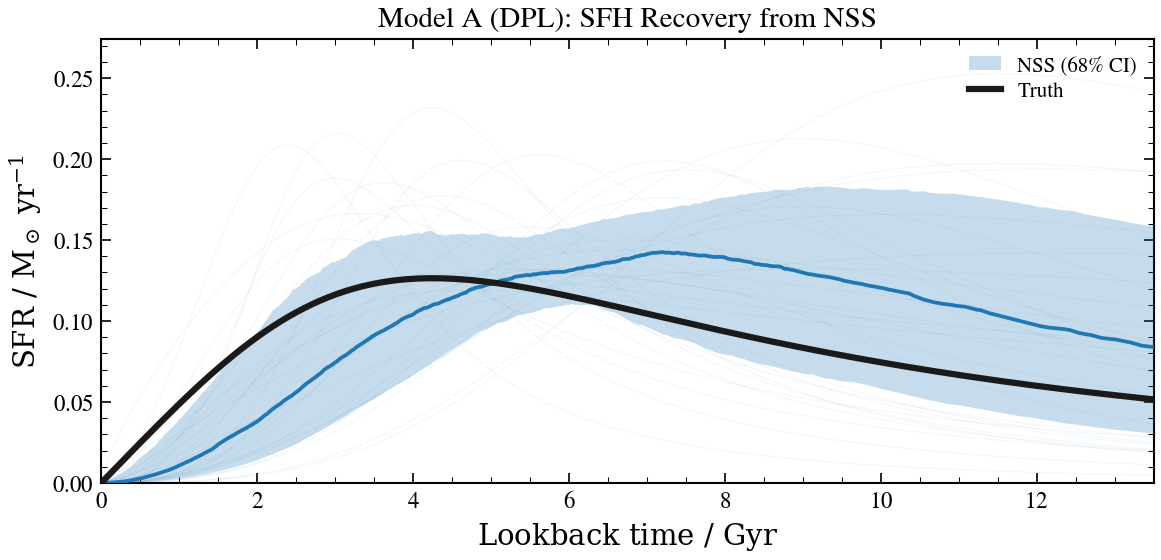

In [15]:
# --- FIGURE 5: SFH recovery for Model A ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(
    model_A,
    result_A,
    true_params=true_params_A,
    ax=ax,
    color=COLORS["rt"],
    label="NSS",
    method="RT",
)
ax.set_title("Model A (DPL): SFH Recovery from NSS")
fig.tight_layout()
plt.savefig(
    os.path.join(FIGDIR, "fig05_sfh_recovery_A.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [16]:
# --- Parameter recovery table for Model A ---
print(f"\n{'Parameter':<25s} {'Truth':>10s} {'Median':>10s} {'68% CI':>20s}")
print("-" * 67)
for pname in spec_A.free_params:
    if pname in result_A.samples and pname in true_params_A:
        chain = np.array(result_A.samples[pname])
        truth_val = float(true_params_A[pname])
        med = float(np.median(chain))
        lo, hi = float(np.percentile(chain, 16)), float(np.percentile(chain, 84))
        print(f"{pname:<25s} {truth_val:10.3f} {med:10.3f} [{lo:8.3f}, {hi:8.3f}]")


Parameter                      Truth     Median               68% CI
-------------------------------------------------------------------
dust_tau_bc                    0.300      0.894 [   0.290,    1.631]
met_logzsol                   -0.500     -0.848 [  -1.102,   -0.529]
sfh_dpl_alpha                  1.500      1.610 [   0.806,    2.541]
sfh_dpl_beta                   1.000      1.995 [   1.270,    2.674]
sfh_dpl_log_peak_sfr          -0.606     -0.490 [  -0.577,   -0.405]
sfh_dpl_tau_gyr                5.000      6.453 [   3.861,    8.926]


## When to Use NSS

| Use case | Method |
|----------|--------|
| **Model comparison** (which SFH, which dust law?) | NSS |
| **Parameter estimation** (smooth, D ≤ 30) | geoVI or NUTS (faster) |
| **Parameter estimation** (stochastic, D ~ 137) | geoVI or Ray Tracing |
| **Quick evidence from MAP** (Gaussian approx.) | Laplace |

NSS is **not** a replacement for geoVI or Ray Tracing for parameter
estimation — it's slower for that purpose. Its unique value is the
evidence integral for principled model selection.

### Computational Notes

- First call includes JIT compilation (~10–30s). Subsequent calls are faster.
- `n_live=500` with `num_delete=50` is a good default.
- For higher precision on log Z, increase `n_live` (evidence error ∝ 1/√n_live).
- NSS uses covariance-adaptive directions (empirical cov of live points),
  so it handles correlations automatically.
- The implementation is a faithful port of the Yallup, Kroupa & Handley (2026)
  algorithm from the handley-lab/blackjax fork, running entirely locally
  with no extra dependencies.